In [1]:
%matplotlib inline
# %matplotlib notebook
from sklearn.model_selection import train_test_split
import numpy as np
import qutip as qt
from entVAE import vae_utils 
import matplotlib.pyplot as plt
import tensorflow as tf


I0000 00:00:1779101142.986551   40789 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779101143.015730   40789 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779101144.159224   40789 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
plt.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "font.size": 8,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.4,
        "ytick.major.width": 0.4,
        "xtick.major.size": 2,
        "ytick.major.size": 2,
        "axes.labelsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 8,
    }
)

In [3]:
n_angle = 101
n_samples = 1000
scan_arr = np.linspace(0, np.pi, n_angle)
alpha_arr = np.zeros(101000)
cnt = 0
for theta in scan_arr:
        for _ in (range(n_samples)):
            alpha_arr[cnt] = theta
            cnt += 1

In [4]:
colors = ["#E64B35", "#4DBBD5", "#00A087", "#3C5488", "#F39B7F", "#8491B4"]
markers = ["o", "s", "^", "D", "v", "p"]

MS = 5 
LW = 1.2 
MW = 0.5

# Noisy Dataset  $0.75\beta$

Load Dataset

In [5]:
rho_arr_noisy = np.load('../data/unitary_4x4_101_1000.npy', mmap_mode="r")
X_train_noisy, X_test_noisy, y_train_noisy, y_test_noisy = train_test_split(rho_arr_noisy, alpha_arr, random_state=42)
concurrence_noisy_arr = np.array([qt.concurrence(qt.Qobj(dm.reshape(4,4),dims=[[2,2],[2,2]])) for dm in X_test_noisy])

Load trained VAE and define Hyperparameters:

In [6]:
batch_size = 64
beta = 0.75
learning_rate = 0.0001
lat_dim = 1
hidden_act = "tanh"
final_act = "linear"

encoder, decoder = vae_utils.vae_mlp_4x4(lat_dim, hidden_act, final_act)
encoder.load_weights("../data/encoder_noise_075beta.h5")
decoder.load_weights("../data/decoder_noise_075beta.h5")

vae_noisy = vae_utils.VAE(encoder, decoder, beta)
vae_noisy.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate))

z_mean_noisy, z_log_var_noisy, z_noisy = vae_noisy.encoder.predict(X_test_noisy)

790/790 ━━━━━━━━━━━━━━━━━━━━ 0s 385us/step


Investigate Latent Space

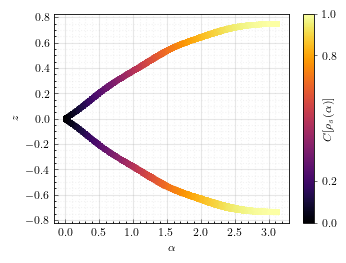

In [7]:
fig, ax = plt.subplots(figsize=(3.5, 2.5))
    
# Rasterize dense markers for faster PDF rendering while keeping text/axes vector.
im = ax.scatter(
    y_test_noisy,
    z_mean_noisy[:, 0],
    c=concurrence_noisy_arr,
    alpha=1,
    zorder=2,
    cmap="inferno",
    s=6,
    linewidths=0,
    rasterized=True
 )
ax.set_xlabel("$\\alpha$")
ax.set_ylabel("$z$")
ax.grid(True, which="major", linestyle="-", alpha=0.3)
ax.grid(True, which="minor", linestyle=":", alpha=0.15)
ax.grid(True, which="major", linestyle="-", alpha=0.3)
ax.grid(True, which="minor", linestyle=":", alpha=0.15)

ax.tick_params(direction="in", which="both", labelsize=8)
ax.tick_params(which="major", length=3)
ax.tick_params(which="minor", length=1.5)
ax.minorticks_on()
cbar = fig.colorbar(im)
fig.text(0.92, 0.47,"$C[\\rho_s(\\alpha)]$",rotation=90)
cbar.set_ticks([0.0,0.2,0.8,1.0])
fig.tight_layout(pad=0.3)
# plt.show()
# plt.savefig("fig_rhos.pdf", bbox_inches="tight", pad_inches=0.1, dpi=300)

